# 04 Results, XAI, and discussion

This notebook turns the project into the final scientific story.

The project investigates whether **Sentinel-2/Sentinel-3 image alignment** improves machine-learning prediction of **Sentinel-2-derived Melt Pond Fraction (MPF)** from **Sentinel-3 OLCI reflectance**.

The main comparison is:
$$
\text{models trained on deliberately misaligned data}
\quad \text{vs} \quad
\text{models trained on ECC-aligned data}
$$
The notebook includes:

1. Final result summary  
2. Best model maps  
3. Alignment improvement plots  
4. Feature importance / Explainable AI  
5. Discussion of why alignment helped  
6. Limitations  
7. Final conclusion

## 1. Setup

This notebook expects outputs from Notebook 2 and Notebook 3.

Required files:

```text
results/metrics_summary.csv
results/alignment_improvement.csv
results/predictions_aligned_vs_misaligned.csv
results/dataset_summary.csv
results/alignment_summary.csv

data/processed/test_data.npz

models/polynomial_aligned.joblib
models/polynomial_noalign.joblib
models/random_forest_aligned.joblib
models/random_forest_noalign.joblib
```

The neural network and Gaussian Process models are used in the result summary, but the main XAI analysis focuses on Polynomial Regression and Random Forest because they provide clearer feature-importance outputs.

In [2]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

PROJECT_DIR = Path("/content/drive/MyDrive/GEOL0069_S2S3_MPF_Alignment_Regression")

DATA_PROCESSED = PROJECT_DIR / "data" / "processed"
RESULTS_DIR = PROJECT_DIR / "results"
MODEL_DIR = PROJECT_DIR / "models"

FIG_REG_DIR = PROJECT_DIR / "figures" / "regression_results"
FIG_XAI_DIR = PROJECT_DIR / "figures" / "xai"

FIG_REG_DIR.mkdir(parents=True, exist_ok=True)
FIG_XAI_DIR.mkdir(parents=True, exist_ok=True)

print("Project directory:", PROJECT_DIR)
print("Results directory:", RESULTS_DIR)
print("Model directory:", MODEL_DIR)
print("Regression figures:", FIG_REG_DIR)
print("XAI figures:", FIG_XAI_DIR)

Project directory: /content/drive/MyDrive/GEOL0069_S2S3_MPF_Alignment_Regression
Results directory: /content/drive/MyDrive/GEOL0069_S2S3_MPF_Alignment_Regression/results
Model directory: /content/drive/MyDrive/GEOL0069_S2S3_MPF_Alignment_Regression/models
Regression figures: /content/drive/MyDrive/GEOL0069_S2S3_MPF_Alignment_Regression/figures/regression_results
XAI figures: /content/drive/MyDrive/GEOL0069_S2S3_MPF_Alignment_Regression/figures/xai


## 2. Load final result tables

Notebook 3 saved the main model metrics and predictions. Notebook 2 saved the dataset and alignment summaries.

The final analysis starts by loading these outputs rather than retraining every model.

In [4]:
def load_csv_with_fallback(filename, folders):
    for folder in folders:
        path = folder / filename
        if path.exists():
            print(f"Loaded {filename} from {path}")
            return pd.read_csv(path)
    raise FileNotFoundError(f"Could not find {filename} in: {folders}")

metrics_df = load_csv_with_fallback(
    "metrics_summary.csv",
    [RESULTS_DIR, FIG_REG_DIR, DATA_PROCESSED]
)

predictions_df = load_csv_with_fallback(
    "predictions_aligned_vs_misaligned.csv",
    [RESULTS_DIR, FIG_REG_DIR, DATA_PROCESSED]
)

# These may have been saved by Notebook 2 in either results/ or data/processed/
dataset_summary = load_csv_with_fallback(
    "dataset_summary.csv",
    [RESULTS_DIR, DATA_PROCESSED, PROJECT_DIR]
)

alignment_summary = load_csv_with_fallback(
    "alignment_summary.csv",
    [RESULTS_DIR, DATA_PROCESSED, PROJECT_DIR]
)

Loaded metrics_summary.csv from /content/drive/MyDrive/GEOL0069_S2S3_MPF_Alignment_Regression/results/metrics_summary.csv
Loaded predictions_aligned_vs_misaligned.csv from /content/drive/MyDrive/GEOL0069_S2S3_MPF_Alignment_Regression/results/predictions_aligned_vs_misaligned.csv
Loaded dataset_summary.csv from /content/drive/MyDrive/GEOL0069_S2S3_MPF_Alignment_Regression/results/dataset_summary.csv
Loaded alignment_summary.csv from /content/drive/MyDrive/GEOL0069_S2S3_MPF_Alignment_Regression/results/alignment_summary.csv


In [5]:
display(metrics_df)
display(dataset_summary)
display(alignment_summary)

,Model,Training dataset,MSE,RMSE,MAE,R2
0,Gaussian Process,Aligned,0.000265,0.016275,0.011560,-0.038569
1,Gaussian Process,Misaligned,0.000263,0.016206,0.011507,-0.029767
2,Neural Network,Aligned,0.000180,0.013404,0.010395,0.295483
3,Neural Network,Misaligned,0.000568,0.023833,0.017542,-1.227269
4,Polynomial Regression,Aligned,0.000127,0.011290,0.008202,0.500219
5,Polynomial Regression,Misaligned,0.000219,0.014782,0.010884,0.143251
6,Random Forest,Aligned,0.000177,0.013300,0.009994,0.306405
7,Random Forest,Misaligned,0.000287,0.016949,0.012747,-0.126328


,dataset,n_samples,n_features,mpf_min,mpf_max,mpf_mean,mpf_std,mean_s2_count,mean_distance
0,training_noalign,4725,21,0.0,0.244595,0.014199,0.014320,212.063704,111.842821
1,training_aligned,4732,21,0.0,0.249488,0.014181,0.014245,211.750000,111.765256
2,test,2386,21,0.0,0.190323,0.016927,0.015970,210.184828,111.554121


,manual_dx,manual_dy,ecc_dx,ecc_dy,residual_dx,residual_dy,residual_shift_m,ecc_correlation
0,1500.0,-1500.0,1913.9246,-1232.0336,-413.92456,-267.96643,493.09183,0.636547


## 3. Dataset creation summary

The regression dataset uses:

\[
X = \text{Sentinel-3 OLCI 21-band reflectance}
\]

\[
y = \text{Sentinel-2-derived MPF averaged onto the Sentinel-3 grid}
\]

The aligned and misaligned datasets should have similar sample sizes and the same number of input features. This makes the later model comparison fair because the main difference is the spatial quality of the S2/S3 input-target pairing.

In [6]:
# Standardise expected column names if needed
display(dataset_summary)

# Optional compact printed summary
for _, row in dataset_summary.iterrows():
    print(
        f"{row['dataset']}: "
        f"{int(row['n_samples'])} samples, "
        f"{int(row['n_features'])} features, "
        f"MPF mean = {row['mpf_mean']:.5f}, "
        f"MPF std = {row['mpf_std']:.5f}"
    )

,dataset,n_samples,n_features,mpf_min,mpf_max,mpf_mean,mpf_std,mean_s2_count,mean_distance
0,training_noalign,4725,21,0.0,0.244595,0.014199,0.014320,212.063704,111.842821
1,training_aligned,4732,21,0.0,0.249488,0.014181,0.014245,211.750000,111.765256
2,test,2386,21,0.0,0.190323,0.016927,0.015970,210.184828,111.554121


training_noalign: 4725 samples, 21 features, MPF mean = 0.01420, MPF std = 0.01432
training_aligned: 4732 samples, 21 features, MPF mean = 0.01418, MPF std = 0.01424
test: 2386 samples, 21 features, MPF mean = 0.01693, MPF std = 0.01597


## 4. Alignment result summary

The imposed manual shift is compared with the ECC-recovered correction.

The shift error is calculated as:

\[
\text{shift error}
=
\sqrt{
(dx_\text{manual} - dx_\text{ECC})^2
+
(dy_\text{manual} - dy_\text{ECC})^2
}
\]

A non-zero residual shift is expected because Sentinel-2 and Sentinel-3 have different resolutions and spectral properties. ECC also assumes a simple translational correction, while real sea-ice motion may include deformation, rotation, or non-uniform drift.

In [7]:
display(alignment_summary)

row = alignment_summary.iloc[0]

manual_dx = row["manual_dx"]
manual_dy = row["manual_dy"]
ecc_dx = row["ecc_dx"]
ecc_dy = row["ecc_dy"]
residual_shift_m = row["residual_shift_m"]
ecc_corr = row.get("ecc_correlation", np.nan)

print(f"Manual shift: dx = {manual_dx:.2f} m, dy = {manual_dy:.2f} m")
print(f"ECC recovered shift: dx = {ecc_dx:.2f} m, dy = {ecc_dy:.2f} m")
print(f"Residual shift error: {residual_shift_m:.2f} m")
print(f"ECC correlation: {ecc_corr:.3f}")

,manual_dx,manual_dy,ecc_dx,ecc_dy,residual_dx,residual_dy,residual_shift_m,ecc_correlation
0,1500.0,-1500.0,1913.9246,-1232.0336,-413.92456,-267.96643,493.09183,0.636547


Manual shift: dx = 1500.00 m, dy = -1500.00 m
ECC recovered shift: dx = 1913.92 m, dy = -1232.03 m
Residual shift error: 493.09 m
ECC correlation: 0.637


## 5. Regression metrics

For every model, the evaluation metrics are:

\[
MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y}_i)^2
\]

\[
RMSE = \sqrt{MSE}
\]

\[
MAE = \frac{1}{n}\sum_{i=1}^{n}|y_i-\hat{y}_i|
\]

\[
R^2 =
1 -
\frac{\sum_i(y_i-\hat{y}_i)^2}
{\sum_i(y_i-\bar{y})^2}
\]

The same independent test dataset is used for all aligned and misaligned model comparisons.

In [8]:
def evaluate_regression(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return mse, rmse, mae, r2

# Sort so the best R2 is easy to see
metrics_ranked = metrics_df.sort_values("R2", ascending=False).reset_index(drop=True)
display(metrics_ranked)

metrics_ranked.to_csv(RESULTS_DIR / "final_ranked_model_metrics.csv", index=False)

,Model,Training dataset,MSE,RMSE,MAE,R2
0,Polynomial Regression,Aligned,0.000127,0.011290,0.008202,0.500219
1,Random Forest,Aligned,0.000177,0.013300,0.009994,0.306405
2,Neural Network,Aligned,0.000180,0.013404,0.010395,0.295483
3,Polynomial Regression,Misaligned,0.000219,0.014782,0.010884,0.143251
4,Gaussian Process,Misaligned,0.000263,0.016206,0.011507,-0.029767
5,Gaussian Process,Aligned,0.000265,0.016275,0.011560,-0.038569
6,Random Forest,Misaligned,0.000287,0.016949,0.012747,-0.126328
7,Neural Network,Misaligned,0.000568,0.023833,0.017542,-1.227269


## 6. Metric comparison plots

The next plots compare aligned and misaligned training for each model.

Lower values are better for:

\[
MSE,\quad RMSE,\quad MAE
\]

Higher values are better for:

\[
R^2
\]

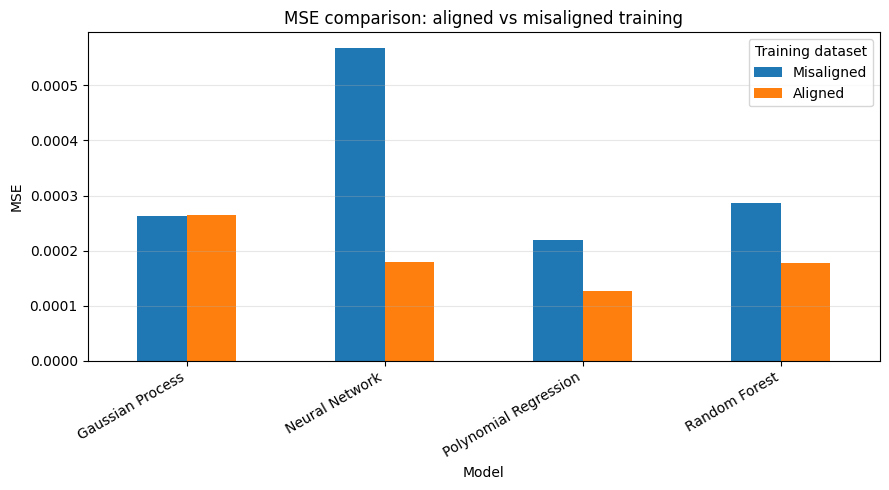

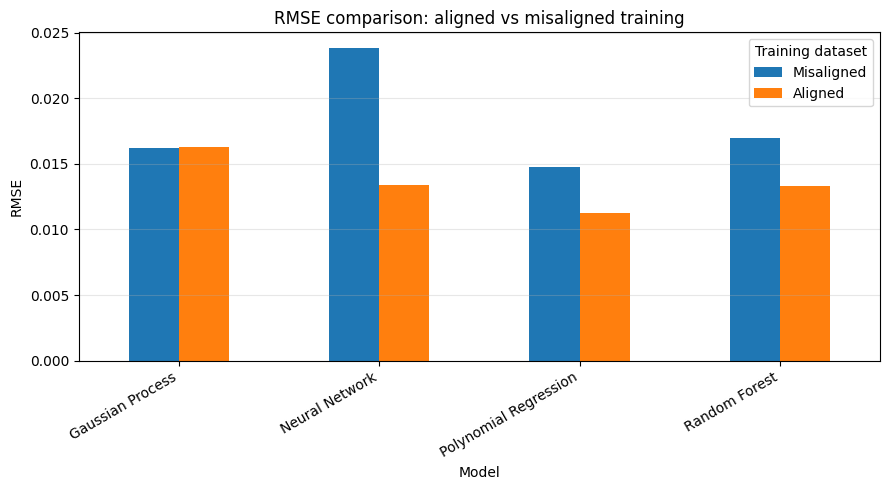

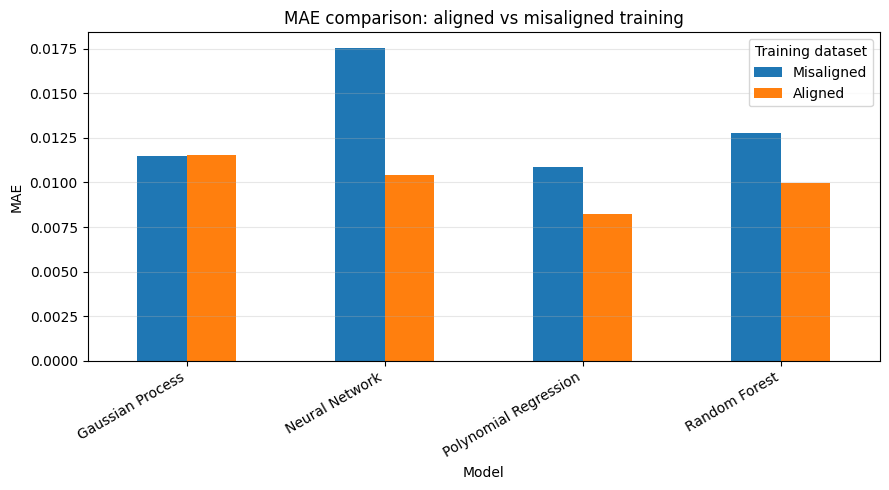

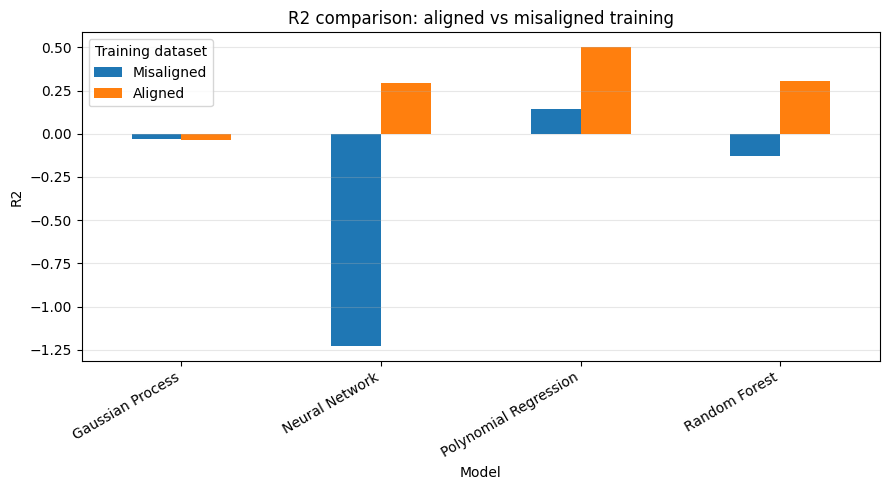

In [28]:
def plot_metric_comparison(metrics_df, metric, save_path):
    df = metrics_df.copy()

    # Keep only aligned/misaligned datasets for comparison
    df = df[df["Training dataset"].isin(["Aligned", "Misaligned"])]

    pivot = df.pivot(index="Model", columns="Training dataset", values=metric)

    # Consistent order if both columns exist
    columns = [c for c in ["Misaligned", "Aligned"] if c in pivot.columns]
    pivot = pivot[columns]

    ax = pivot.plot(kind="bar", figsize=(9, 5))
    ax.set_ylabel(metric)
    ax.set_title(f"{metric} comparison: aligned vs misaligned training")
    ax.grid(axis="y", alpha=0.3)
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.show()

plot_metric_comparison(metrics_df, "MSE", FIG_REG_DIR / "final_mse_comparison.png")
plot_metric_comparison(metrics_df, "RMSE", FIG_REG_DIR / "final_rmse_comparison.png")
plot_metric_comparison(metrics_df, "MAE", FIG_REG_DIR / "final_mae_comparison.png")
plot_metric_comparison(metrics_df, "R2", FIG_REG_DIR / "final_r2_comparison.png")

The MAE comparison shows the average absolute MPF prediction error for each model. Lower MAE indicates better performance. Including MAE alongside MSE and RMSE is useful because MAE is less sensitive to large individual errors and gives a more direct interpretation of the average prediction error in MPF units.

## 7. Alignment improvement table

The alignment improvement is calculated as:

\[
\text{MSE improvement}
=
100
\frac{MSE_\text{misaligned}-MSE_\text{aligned}}
{MSE_\text{misaligned}}
\]

A positive value means that the aligned model had lower MSE than the misaligned model.

The change in \(R^2\) is:

\[
\Delta R^2
=
R^2_\text{aligned}
-
R^2_\text{misaligned}
\]

In [10]:
improvement_rows = []

for model_name in sorted(metrics_df["Model"].unique()):
    subset = metrics_df[metrics_df["Model"] == model_name]

    aligned = subset[subset["Training dataset"] == "Aligned"]
    misaligned = subset[subset["Training dataset"] == "Misaligned"]

    if len(aligned) == 1 and len(misaligned) == 1:
        mse_aligned = aligned["MSE"].values[0]
        mse_misaligned = misaligned["MSE"].values[0]
        rmse_aligned = aligned["RMSE"].values[0]
        rmse_misaligned = misaligned["RMSE"].values[0]
        mae_aligned = aligned["MAE"].values[0]
        mae_misaligned = misaligned["MAE"].values[0]
        r2_aligned = aligned["R2"].values[0]
        r2_misaligned = misaligned["R2"].values[0]

        improvement_rows.append({
            "Model": model_name,
            "MSE aligned": mse_aligned,
            "MSE misaligned": mse_misaligned,
            "MSE improvement (%)": 100 * (mse_misaligned - mse_aligned) / mse_misaligned,
            "RMSE improvement (%)": 100 * (rmse_misaligned - rmse_aligned) / rmse_misaligned,
            "MAE improvement (%)": 100 * (mae_misaligned - mae_aligned) / mae_misaligned,
            "R2 aligned": r2_aligned,
            "R2 misaligned": r2_misaligned,
            "R2 change": r2_aligned - r2_misaligned
        })

improvement_df = pd.DataFrame(improvement_rows)
display(improvement_df)

improvement_df.to_csv(RESULTS_DIR / "final_alignment_improvement.csv", index=False)

,Model,MSE aligned,MSE misaligned,MSE improvement (%),RMSE improvement (%),MAE improvement (%),R2 aligned,R2 misaligned,R2 change
0,Gaussian Process,0.000265,0.000263,-0.854749,-0.426465,-0.464153,-0.038569,-0.029767,-0.008802
1,Neural Network,0.000180,0.000568,68.368587,43.758189,40.742729,0.295483,-1.227269,1.522752
2,Polynomial Regression,0.000127,0.000219,41.665461,23.622949,24.644777,0.500219,0.143251,0.356968
3,Random Forest,0.000177,0.000287,38.419752,21.526916,21.599906,0.306405,-0.126328,0.432732


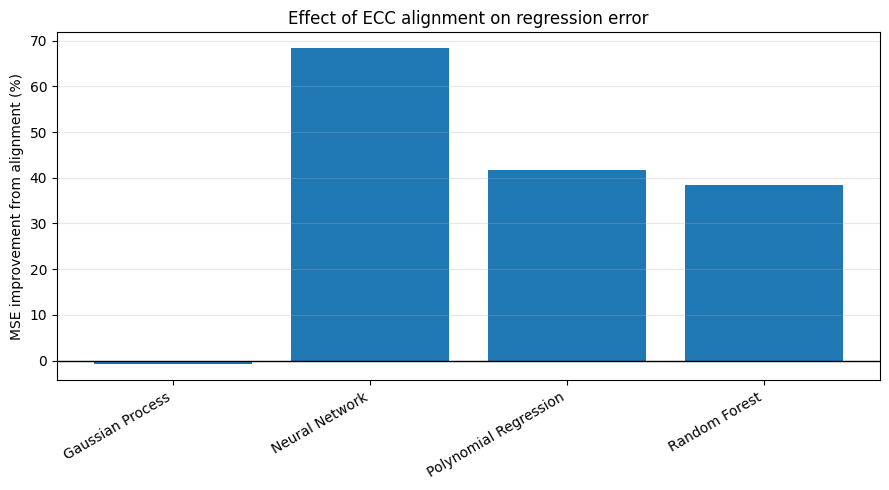

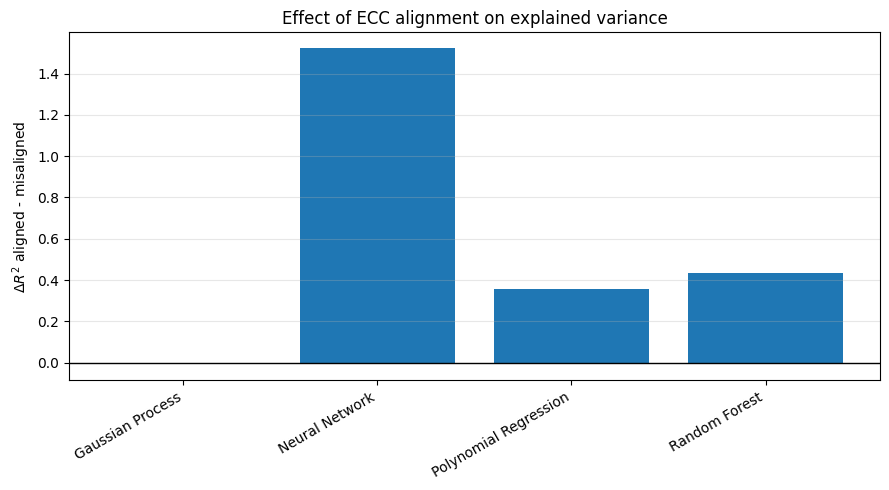

In [11]:
plt.figure(figsize=(9, 5))
plt.bar(improvement_df["Model"], improvement_df["MSE improvement (%)"])
plt.axhline(0, color="black", linewidth=1)
plt.ylabel("MSE improvement from alignment (%)")
plt.title("Effect of ECC alignment on regression error")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_REG_DIR / "final_alignment_mse_improvement.png", dpi=300)
plt.show()

plt.figure(figsize=(9, 5))
plt.bar(improvement_df["Model"], improvement_df["R2 change"])
plt.axhline(0, color="black", linewidth=1)
plt.ylabel(r"$\Delta R^2$ aligned - misaligned")
plt.title("Effect of ECC alignment on explained variance")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_REG_DIR / "final_alignment_r2_change.png", dpi=300)
plt.show()

## 8. Identify the best model

The best model is selected using the highest \(R^2\) on the independent test region. If several models have similar \(R^2\), MSE/RMSE and spatial residual maps should also be considered.

In [12]:
comparison_df = metrics_df[metrics_df["Training dataset"].isin(["Aligned", "Misaligned"])].copy()
best_row = comparison_df.sort_values("R2", ascending=False).iloc[0]

best_model = best_row["Model"]
best_training = best_row["Training dataset"]

print("Best model:")
print(f"  Model: {best_model}")
print(f"  Training dataset: {best_training}")
print(f"  MSE: {best_row['MSE']:.6f}")
print(f"  RMSE: {best_row['RMSE']:.6f}")
print(f"  MAE: {best_row['MAE']:.6f}")
print(f"  R2: {best_row['R2']:.3f}")

Best model:
  Model: Polynomial Regression
  Training dataset: Aligned
  MSE: 0.000127
  RMSE: 0.011290
  MAE: 0.008202
  R2: 0.500


## 9. Best model maps

The final spatial result is shown using three maps:

1. Actual Sentinel-2-derived MPF on the independent test region  
2. Best model predicted MPF  
3. Residual map  

Here residuals are defined as:

\[
r_i = y_i - \hat{y}_i
\]

where:

\[
y_i = \text{actual MPF}
\]

and:

\[
\hat{y}_i = \text{predicted MPF}
\]

With this convention:

\[
r_i > 0
\]

means the model **underpredicted** MPF, and:

\[
r_i < 0
\]

means the model **overpredicted** MPF.

In [13]:
def prediction_column_name(model_name, training_dataset):
    model_map = {
        "Polynomial Regression": "poly",
        "Random Forest": "rf",
        "Neural Network": "nn",
        "Gaussian Process": "gpr"
    }

    train_map = {
        "Aligned": "aligned",
        "Misaligned": "noalign"
    }

    if model_name not in model_map:
        raise ValueError(f"No prediction column mapping for model: {model_name}")

    if training_dataset not in train_map:
        raise ValueError(f"No prediction column mapping for training dataset: {training_dataset}")

    return f"{model_map[model_name]}_{train_map[training_dataset]}"

best_pred_col = prediction_column_name(best_model, best_training)
print("Using prediction column:", best_pred_col)

x = predictions_df["x"].values
y_coord = predictions_df["y_coord"].values
actual_mpf = predictions_df["actual_mpf"].values
best_pred = predictions_df[best_pred_col].values

best_residual = actual_mpf - best_pred

Using prediction column: poly_aligned


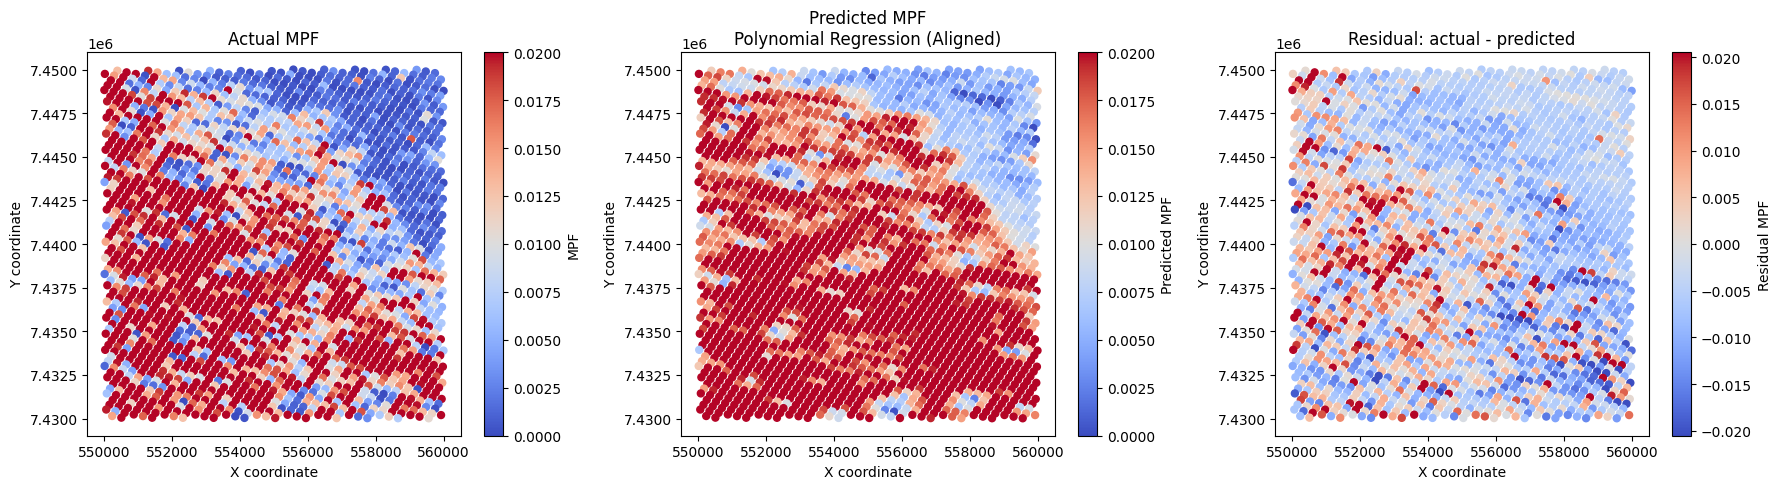

In [14]:
def spatial_map(ax, x, y, values, title, vmin=None, vmax=None, cmap="coolwarm", label="MPF"):
    sc = ax.scatter(x, y, c=values, s=25, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_xlabel("X coordinate")
    ax.set_ylabel("Y coordinate")
    ax.set_title(title)
    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label(label)
    return sc

# MPF scale capped at 0.02 for visual clarity
mpf_vmin, mpf_vmax = 0, 0.02

resid_vmax = np.nanpercentile(np.abs(best_residual), 95)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

spatial_map(
    axes[0], x, y_coord, actual_mpf,
    "Actual MPF",
    vmin=mpf_vmin, vmax=mpf_vmax,
    label="MPF"
)

spatial_map(
    axes[1], x, y_coord, best_pred,
    f"Predicted MPF\n{best_model} ({best_training})",
    vmin=mpf_vmin, vmax=mpf_vmax,
    label="Predicted MPF"
)

spatial_map(
    axes[2], x, y_coord, best_residual,
    "Residual: actual - predicted",
    vmin=-resid_vmax, vmax=resid_vmax,
    label="Residual MPF"
)

plt.tight_layout()
plt.savefig(FIG_REG_DIR / "best_model_actual_prediction_residual_maps.png", dpi=300)
plt.show()

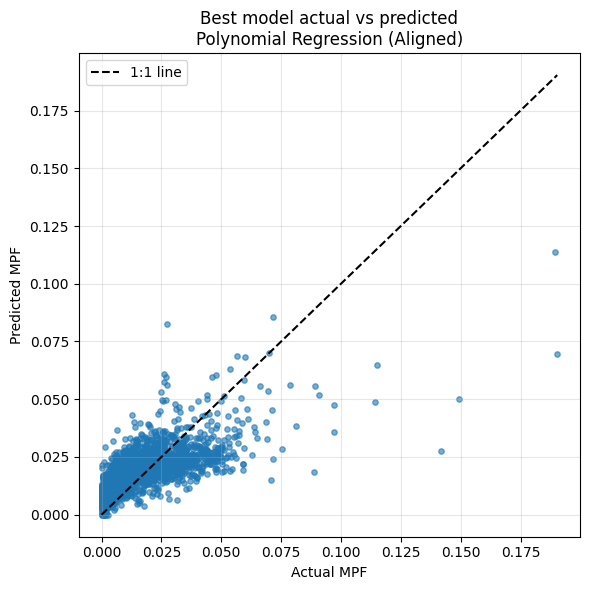

In [15]:
plt.figure(figsize=(6, 6))
plt.scatter(actual_mpf, best_pred, s=15, alpha=0.6)

min_val = min(np.nanmin(actual_mpf), np.nanmin(best_pred))
max_val = max(np.nanmax(actual_mpf), np.nanmax(best_pred))

plt.plot([min_val, max_val], [min_val, max_val], "k--", label="1:1 line")
plt.xlabel("Actual MPF")
plt.ylabel("Predicted MPF")
plt.title(f"Best model actual vs predicted\n{best_model} ({best_training})")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_REG_DIR / "best_model_actual_vs_predicted.png", dpi=300)
plt.show()

## 10. Explainable AI: feature importance

Feature importance is used to understand which Sentinel-3 OLCI bands most strongly influence the regression models.

The main XAI methods used here are:

1. **Polynomial coefficient importance**  
   Large absolute coefficients indicate terms that strongly affect the prediction.

2. **Random Forest feature importance**  
   Bands that produce larger reductions in prediction error across trees receive higher importance.

3. **Permutation importance**  
   Each band is shuffled in the test dataset, and the decrease in model performance is measured. A large drop means the feature was important.

The interpretation should not stop at “Band X is important.” The scientific question is whether the important OLCI bands represent spectral information that is physically linked to melt ponds, sea ice, and mixed surface types.

## 11. Polynomial Regression coefficient importance

For degree-2 Polynomial Regression, the expanded model includes:

- original OLCI bands,
- squared terms,
- interaction terms.

Therefore, two feature-importance views are useful:

1. The top polynomial terms by absolute coefficient.
2. Aggregated OLCI band importance, where coefficients involving each band are summed.

In [16]:
poly_aligned_path = MODEL_DIR / "polynomial_aligned.joblib"
poly_noalign_path = MODEL_DIR / "polynomial_noalign.joblib"

poly_aligned = joblib.load(poly_aligned_path)
poly_noalign = joblib.load(poly_noalign_path)

olci_band_names = [f"OLCI_{i+1}" for i in range(21)]

def polynomial_importance_table(poly_model, band_names):
    poly_step = poly_model.named_steps["poly"]
    reg_step = poly_model.named_steps["regressor"]

    feature_names = poly_step.get_feature_names_out(band_names)
    coeffs = reg_step.coef_

    table = pd.DataFrame({
        "feature": feature_names,
        "coefficient": coeffs,
        "abs_coefficient": np.abs(coeffs)
    }).sort_values("abs_coefficient", ascending=False)

    return table

poly_imp_aligned = polynomial_importance_table(poly_aligned, olci_band_names)
poly_imp_noalign = polynomial_importance_table(poly_noalign, olci_band_names)

display(poly_imp_aligned.head(15))
display(poly_imp_noalign.head(15))

poly_imp_aligned.to_csv(RESULTS_DIR / "xai_polynomial_coefficients_aligned.csv", index=False)
poly_imp_noalign.to_csv(RESULTS_DIR / "xai_polynomial_coefficients_noalign.csv", index=False)

,feature,coefficient,abs_coefficient
71,OLCI_3 OLCI_12,-0.013796,0.013796
21,OLCI_1^2,-0.013074,0.013074
11,OLCI_12,-0.012883,0.012883
17,OLCI_18,0.012802,0.012802
38,OLCI_1 OLCI_18,0.012674,0.012674
26,OLCI_1 OLCI_6,0.012624,0.012624
52,OLCI_2 OLCI_12,-0.012313,0.012313
18,OLCI_19,0.012123,0.012123
46,OLCI_2 OLCI_6,0.011853,0.011853
32,OLCI_1 OLCI_12,-0.011243,0.011243


,feature,coefficient,abs_coefficient
5,OLCI_6,-0.021597,0.021597
11,OLCI_12,0.020006,0.020006
14,OLCI_15,-0.019157,0.019157
18,OLCI_19,-0.019118,0.019118
17,OLCI_18,0.016455,0.016455
15,OLCI_16,0.014563,0.014563
20,OLCI_21,-0.013701,0.013701
13,OLCI_14,-0.012548,0.012548
4,OLCI_5,-0.012457,0.012457
16,OLCI_17,0.012317,0.012317


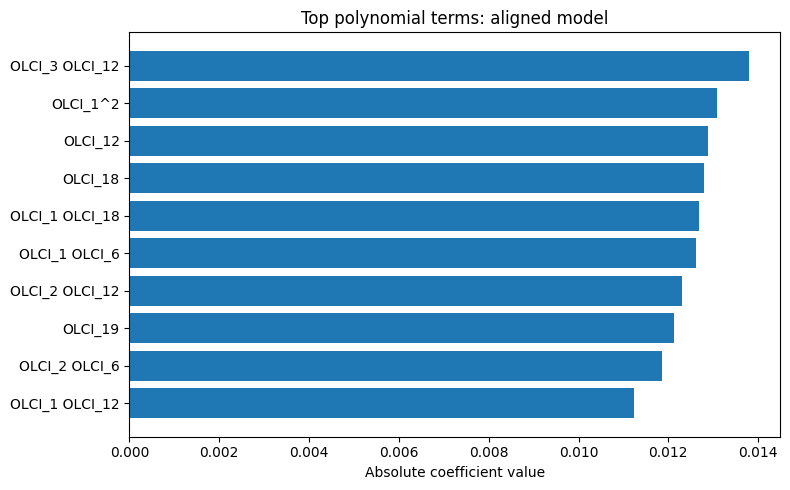

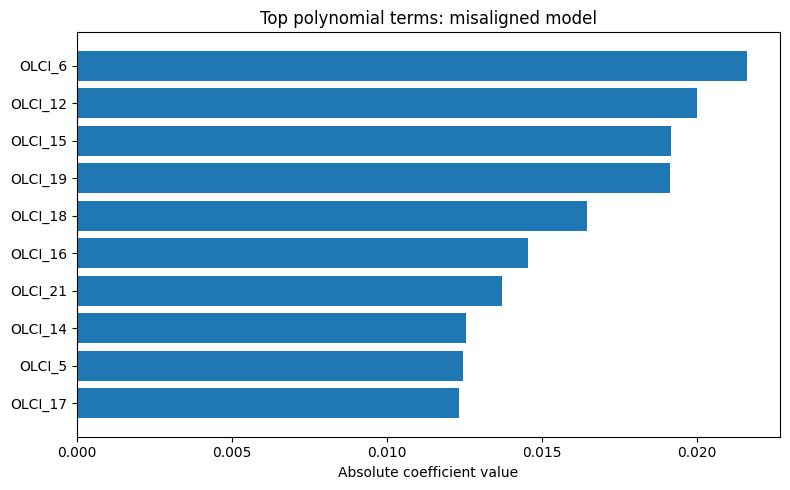

In [17]:
def plot_top_polynomial_terms(table, title, save_path, top_n=10):
    top = table.head(top_n).iloc[::-1]

    plt.figure(figsize=(8, 5))
    plt.barh(top["feature"], top["abs_coefficient"])
    plt.xlabel("Absolute coefficient value")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.show()

plot_top_polynomial_terms(
    poly_imp_aligned,
    "Top polynomial terms: aligned model",
    FIG_XAI_DIR / "top_polynomial_terms_aligned.png"
)

plot_top_polynomial_terms(
    poly_imp_noalign,
    "Top polynomial terms: misaligned model",
    FIG_XAI_DIR / "top_polynomial_terms_noalign.png"
)

In [18]:
def aggregate_polynomial_band_importance(poly_table, band_names):
    importance = {band: 0.0 for band in band_names}

    for _, row in poly_table.iterrows():
        feature = row["feature"]
        value = row["abs_coefficient"]

        for band in band_names:
            # Match band as a token: OLCI_1 should not match OLCI_10
            if re.search(rf"\b{band}\b", feature):
                importance[band] += value

    out = pd.DataFrame({
        "band": list(importance.keys()),
        "importance": list(importance.values())
    })

    out["band_number"] = out["band"].str.replace("OLCI_", "", regex=False).astype(int)
    out = out.sort_values("importance", ascending=False)

    return out

import re

poly_band_imp_aligned = aggregate_polynomial_band_importance(poly_imp_aligned, olci_band_names)
poly_band_imp_noalign = aggregate_polynomial_band_importance(poly_imp_noalign, olci_band_names)

display(poly_band_imp_aligned.head(10))
display(poly_band_imp_noalign.head(10))

poly_band_imp_aligned.to_csv(RESULTS_DIR / "xai_polynomial_band_importance_aligned.csv", index=False)
poly_band_imp_noalign.to_csv(RESULTS_DIR / "xai_polynomial_band_importance_noalign.csv", index=False)

,band,importance,band_number
11,OLCI_12,0.137862,12
0,OLCI_1,0.137105,1
1,OLCI_2,0.121528,2
5,OLCI_6,0.116244,6
2,OLCI_3,0.111962,3
3,OLCI_4,0.111235,4
4,OLCI_5,0.108921,5
15,OLCI_16,0.105920,16
20,OLCI_21,0.101098,21
10,OLCI_11,0.096466,11


,band,importance,band_number
19,OLCI_20,0.070931,20
13,OLCI_14,0.067481,14
12,OLCI_13,0.064251,13
14,OLCI_15,0.062775,15
1,OLCI_2,0.060072,2
20,OLCI_21,0.058640,21
3,OLCI_4,0.058152,4
0,OLCI_1,0.058034,1
5,OLCI_6,0.052986,6
17,OLCI_18,0.051683,18


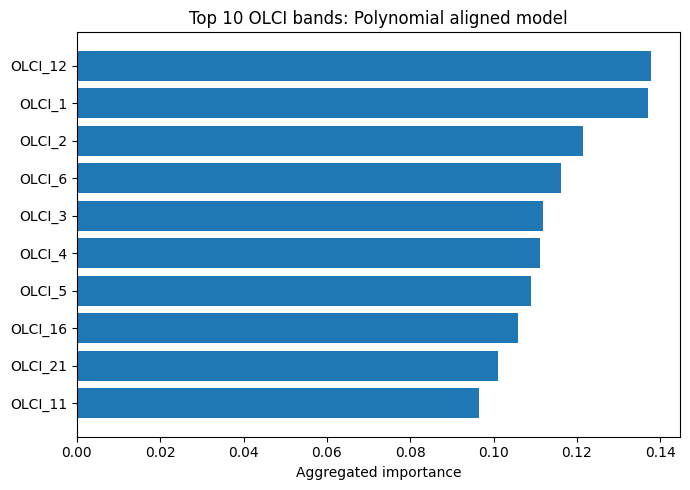

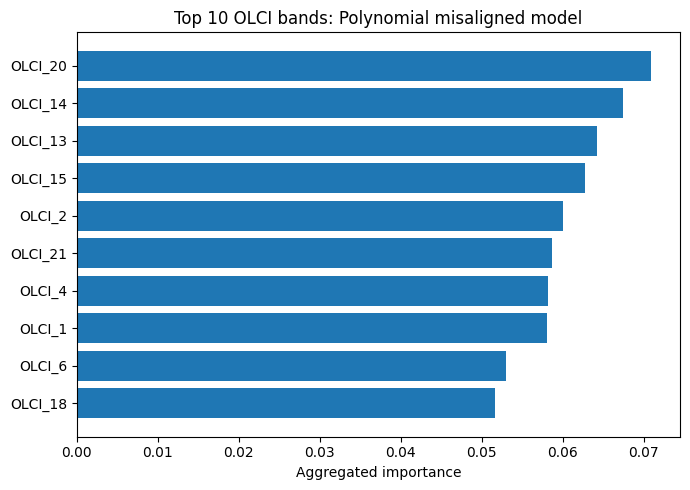

In [19]:
def plot_top_band_importance(df, title, save_path, top_n=10):
    top = df.head(top_n).iloc[::-1]

    plt.figure(figsize=(7, 5))
    plt.barh(top["band"], top["importance"])
    plt.xlabel("Aggregated importance")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.show()

plot_top_band_importance(
    poly_band_imp_aligned,
    "Top 10 OLCI bands: Polynomial aligned model",
    FIG_XAI_DIR / "top10_olci_bands_polynomial_aligned.png"
)

plot_top_band_importance(
    poly_band_imp_noalign,
    "Top 10 OLCI bands: Polynomial misaligned model",
    FIG_XAI_DIR / "top10_olci_bands_polynomial_noalign.png"
)

## 12. Random Forest feature importance

Random Forest feature importance gives one importance score for each original OLCI band. This is useful because it is easier to interpret than polynomial interaction terms.

Higher values indicate that the band contributed more strongly to reducing prediction error across the ensemble of decision trees.

In [20]:
rf_aligned_path = MODEL_DIR / "random_forest_aligned.joblib"
rf_noalign_path = MODEL_DIR / "random_forest_noalign.joblib"

rf_aligned = joblib.load(rf_aligned_path)
rf_noalign = joblib.load(rf_noalign_path)

rf_imp_aligned = pd.DataFrame({
    "band": olci_band_names,
    "importance": rf_aligned.feature_importances_
})
rf_imp_aligned["band_number"] = np.arange(1, 22)
rf_imp_aligned = rf_imp_aligned.sort_values("importance", ascending=False)

rf_imp_noalign = pd.DataFrame({
    "band": olci_band_names,
    "importance": rf_noalign.feature_importances_
})
rf_imp_noalign["band_number"] = np.arange(1, 22)
rf_imp_noalign = rf_imp_noalign.sort_values("importance", ascending=False)

display(rf_imp_aligned.head(10))
display(rf_imp_noalign.head(10))

rf_imp_aligned.to_csv(RESULTS_DIR / "xai_random_forest_importance_aligned.csv", index=False)
rf_imp_noalign.to_csv(RESULTS_DIR / "xai_random_forest_importance_noalign.csv", index=False)

,band,importance,band_number
20,OLCI_21,0.218612,21
0,OLCI_1,0.184416,1
19,OLCI_20,0.081206,20
1,OLCI_2,0.065803,2
12,OLCI_13,0.053457,13
13,OLCI_14,0.041877,14
2,OLCI_3,0.034906,3
17,OLCI_18,0.033586,18
18,OLCI_19,0.032339,19
5,OLCI_6,0.029316,6


,band,importance,band_number
20,OLCI_21,0.104953,21
19,OLCI_20,0.101620,20
12,OLCI_13,0.066190,13
13,OLCI_14,0.061391,14
0,OLCI_1,0.060577,1
18,OLCI_19,0.052253,19
1,OLCI_2,0.051623,2
2,OLCI_3,0.049303,3
5,OLCI_6,0.047468,6
17,OLCI_18,0.043930,18


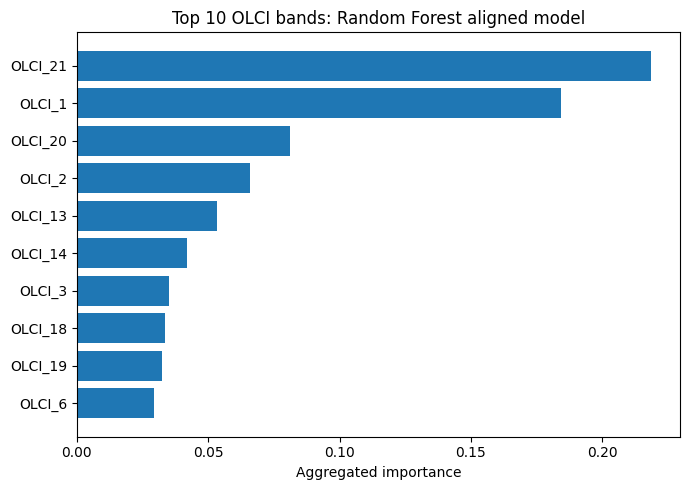

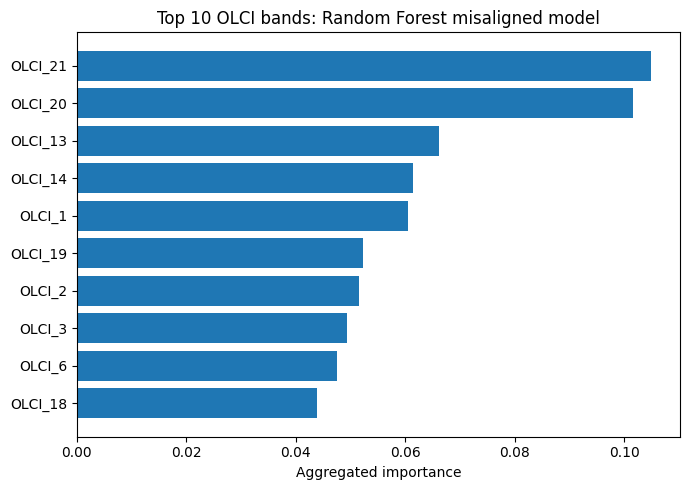

In [21]:
plot_top_band_importance(
    rf_imp_aligned,
    "Top 10 OLCI bands: Random Forest aligned model",
    FIG_XAI_DIR / "top10_olci_bands_rf_aligned.png"
)

plot_top_band_importance(
    rf_imp_noalign,
    "Top 10 OLCI bands: Random Forest misaligned model",
    FIG_XAI_DIR / "top10_olci_bands_rf_noalign.png"
)

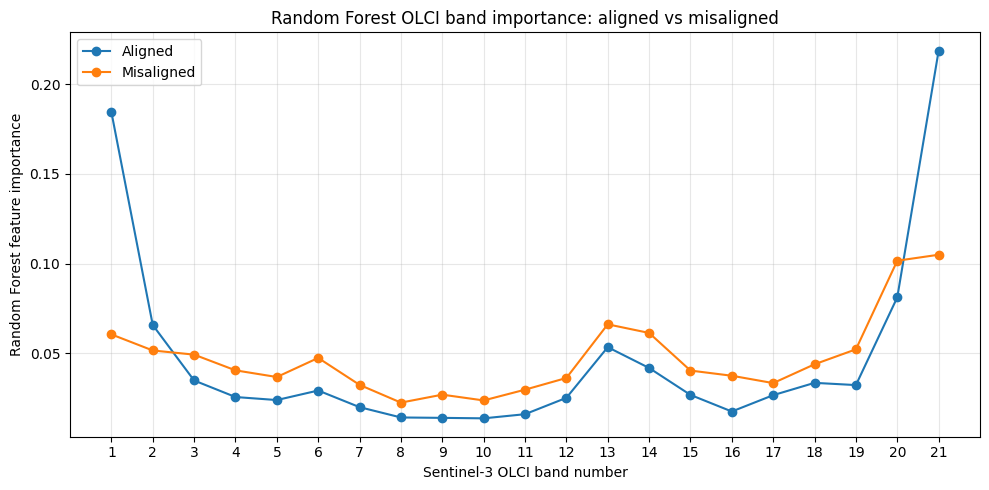

In [22]:
# Compare aligned and misaligned Random Forest band importance
rf_compare = pd.merge(
    rf_imp_aligned[["band", "importance"]].rename(columns={"importance": "aligned"}),
    rf_imp_noalign[["band", "importance"]].rename(columns={"importance": "misaligned"}),
    on="band"
)

rf_compare["band_number"] = rf_compare["band"].str.replace("OLCI_", "", regex=False).astype(int)
rf_compare = rf_compare.sort_values("band_number")

plt.figure(figsize=(10, 5))
plt.plot(rf_compare["band_number"], rf_compare["aligned"], marker="o", label="Aligned")
plt.plot(rf_compare["band_number"], rf_compare["misaligned"], marker="o", label="Misaligned")
plt.xlabel("Sentinel-3 OLCI band number")
plt.ylabel("Random Forest feature importance")
plt.title("Random Forest OLCI band importance: aligned vs misaligned")
plt.xticks(range(1, 22))
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_XAI_DIR / "rf_band_importance_aligned_vs_misaligned.png", dpi=300)
plt.show()

## 13. Permutation importance

Permutation importance tests how much model performance decreases when each OLCI band is randomly shuffled.

If shuffling a band strongly reduces model performance, that band contains important information for MPF prediction.

Permutation importance is often more reliable than default Random Forest impurity-based importance because it measures importance directly on the test dataset.

In [23]:
test_data_path = DATA_PROCESSED / "test_data.npz"
test_data = np.load(test_data_path)

X_test = test_data["s3_features"]
y_test = test_data["mpf_target"]

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_test: (2386, 21)
y_test: (2386,)


In [24]:
perm_rf_aligned = permutation_importance(
    rf_aligned,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="r2",
    n_jobs=-1
)

perm_rf_noalign = permutation_importance(
    rf_noalign,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="r2",
    n_jobs=-1
)

perm_aligned_df = pd.DataFrame({
    "band": olci_band_names,
    "importance_mean": perm_rf_aligned.importances_mean,
    "importance_std": perm_rf_aligned.importances_std
}).sort_values("importance_mean", ascending=False)

perm_noalign_df = pd.DataFrame({
    "band": olci_band_names,
    "importance_mean": perm_rf_noalign.importances_mean,
    "importance_std": perm_rf_noalign.importances_std
}).sort_values("importance_mean", ascending=False)

display(perm_aligned_df.head(10))
display(perm_noalign_df.head(10))

perm_aligned_df.to_csv(RESULTS_DIR / "xai_permutation_importance_rf_aligned.csv", index=False)
perm_noalign_df.to_csv(RESULTS_DIR / "xai_permutation_importance_rf_noalign.csv", index=False)

,band,importance_mean,importance_std
0,OLCI_1,3.045039,0.103752
20,OLCI_21,0.950083,0.024852
1,OLCI_2,0.152450,0.005901
12,OLCI_13,0.079881,0.004219
17,OLCI_18,0.060282,0.004173
2,OLCI_3,0.047332,0.001744
19,OLCI_20,0.044975,0.004350
13,OLCI_14,0.041541,0.003471
16,OLCI_17,0.040387,0.002291
5,OLCI_6,0.035192,0.001734


,band,importance_mean,importance_std
12,OLCI_13,0.167027,0.008084
0,OLCI_1,0.142677,0.006689
13,OLCI_14,0.133834,0.007049
14,OLCI_15,0.059721,0.002851
20,OLCI_21,0.032293,0.003988
1,OLCI_2,0.021448,0.004020
7,OLCI_8,0.013078,0.001075
8,OLCI_9,0.010078,0.001112
9,OLCI_10,0.007022,0.000783
10,OLCI_11,0.003468,0.001223


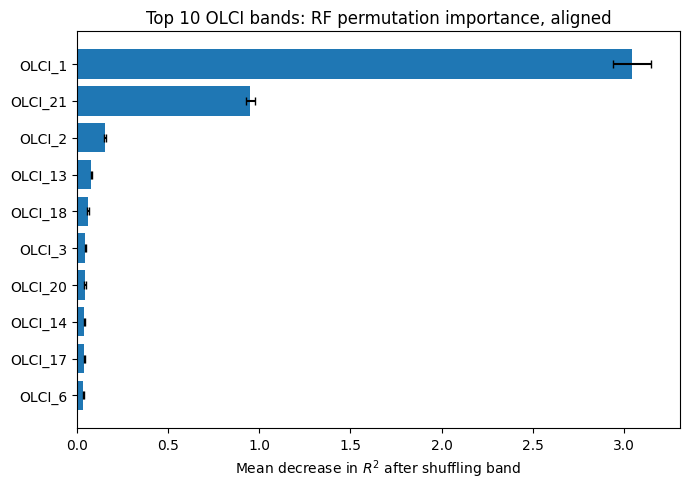

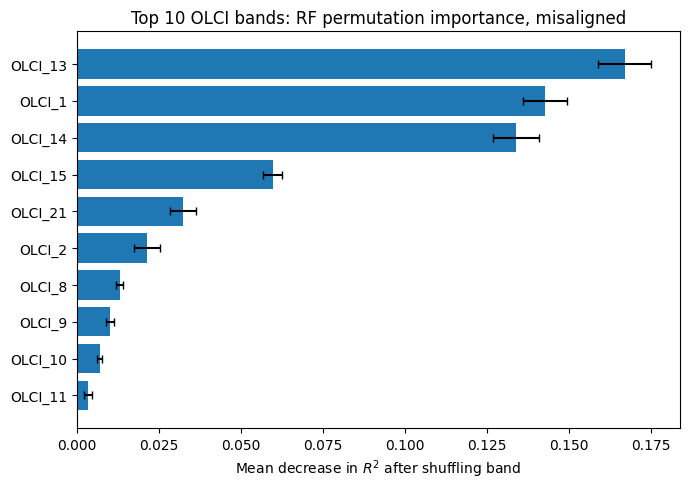

In [29]:
def plot_permutation_importance(df, title, save_path, top_n=10):
    top = df.head(top_n).iloc[::-1]

    plt.figure(figsize=(7, 5))
    plt.barh(
        top["band"],
        top["importance_mean"],
        xerr=top["importance_std"],
        capsize=3
    )
    plt.xlabel("Mean decrease in $R^2$ after shuffling band")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.show()

plot_permutation_importance(
    perm_aligned_df,
    "Top 10 OLCI bands: RF permutation importance, aligned",
    FIG_XAI_DIR / "top10_permutation_importance_rf_aligned.png"
)

plot_permutation_importance(
    perm_noalign_df,
    "Top 10 OLCI bands: RF permutation importance, misaligned",
    FIG_XAI_DIR / "top10_permutation_importance_rf_noalign.png"
)

Permutation importance is reported as the mean decrease in \(R^2\) after shuffling each Sentinel-3 OLCI band. These values are not percentages; larger values mean that shuffling the band caused a larger drop in model performance.

## 14. XAI interpretation

The most important OLCI bands indicate which spectral reflectance information is most strongly linked to Sentinel-2-derived MPF.

The Polynomial Regression analysis shows which original bands or band interactions have the largest coefficients. The Random Forest and permutation importance analyses show which individual OLCI bands contribute most to nonlinear prediction performance.

If the aligned models show clearer or more stable feature-importance patterns than the misaligned models, this supports the interpretation that spatial alignment improves the signal-to-noise ratio of the training data. In other words, the model is more likely to learn physically meaningful spectral-MPF relationships when the Sentinel-3 reflectance and Sentinel-2 MPF target represent more consistent ground locations.

These feature-importance results should be interpreted cautiously because OLCI bands are spectrally correlated, and feature importance does not prove direct causality.

## 15. Why alignment helped

The main reason alignment improves performance is that supervised regression requires physically consistent input-target pairs.

In this project:

$$
X_j = \text{Sentinel-3 OLCI reflectance at location } j
$$

$$
y_j = \text{Sentinel-2-derived MPF assigned to location } j
$$

If S2 and S3 are misaligned, the model may receive an input reflectance vector from one sea-ice surface but an MPF target from a neighbouring surface. This creates label noise.

Misalignment is especially important for sea-ice surfaces because MPF varies over short spatial scales. Small ponds, floe boundaries, leads, and mixed pixels can change quickly over hundreds of metres. Therefore, even a moderate spatial offset can weaken the relationship between OLCI reflectance and MPF.

ECC alignment reduces this mismatch by correcting the imposed translational shift before KDTree colocation. The result is that the aligned training dataset pairs S3 reflectance with more spatially consistent S2-derived MPF values. This explains why most models trained on the aligned dataset achieved lower error and higher \(R^2\).

## Key numerical results

The best-performing model was **Polynomial Regression trained on the ECC-aligned dataset**.

The aligned Polynomial Regression model achieved:

$$
R^2_{\mathrm{aligned}} = 0.500
$$

whereas the misaligned Polynomial Regression model achieved:

$$
R^2_{\mathrm{misaligned}} = 0.143
$$

The improvement in \(R^2\) was therefore:

$$
\Delta R^2 = 0.500 - 0.143 = 0.357
$$

The Polynomial Regression model also showed an MSE improvement of approximately:

$$
41.7\%
$$

The Neural Network also improved strongly after alignment:

$$
R^2_{\mathrm{aligned}} = 0.295
$$

$$
R^2_{\mathrm{misaligned}} = -1.227
$$

The Random Forest model also improved:

$$
R^2_{\mathrm{aligned}} = 0.306
$$

$$
R^2_{\mathrm{misaligned}} = -0.126
$$

The Gaussian Process model did not improve:

$$
R^2_{\mathrm{aligned}} = -0.039
$$

$$
R^2_{\mathrm{misaligned}} = -0.030
$$

Overall, ECC alignment improved three of the four regression models. The strongest result was Polynomial Regression, where alignment increased \(R^2\) from 0.143 to 0.500 and reduced MSE by approximately 41.7%. This supports the hypothesis that spatially consistent Sentinel-2/Sentinel-3 colocation improves the learned relationship between Sentinel-3 OLCI reflectance and Sentinel-2-derived MPF.

## 16. Limitations

This project has several important limitations.

First, the MPF distribution is highly skewed toward low values. Most pixels have very low melt pond fraction, while high-MPF values are rare. This makes regression difficult because models have fewer examples from which to learn high-MPF behaviour.

Second, Sentinel-2 and Sentinel-3 have different spatial resolutions. Sentinel-2 resolves much finer surface detail, while Sentinel-3 OLCI is coarser. Even after alignment, each S3 point represents an average of many finer-scale S2/MPF pixels.

Third, the misalignment experiment uses an artificial shift. This is useful for a controlled experiment, but real sea-ice drift can include translation, rotation, shear, deformation, and non-rigid motion.

Fourth, ECC assumes a simple translational shift. This means it cannot fully correct complex sea-ice deformation or local differences in drift across the scene.

Fifth, the independent test region is spatially separate but still geographically close to the training region. Testing on additional dates, regions, or summer melt conditions would provide a stronger assessment of generalisation.

Sixth, the Sentinel-2-derived MPF target is treated as the reference variable, but it may contain uncertainty from the MPF retrieval method itself. The project therefore evaluates consistency with an S2-derived target rather than direct field-measured melt pond fraction.

Finally, feature importance should be interpreted carefully because Sentinel-3 OLCI bands are correlated. A band may appear important because it is physically meaningful, but also because it is correlated with another useful band.

## 17. Final conclusion

This project shows that the quality of spatial colocation between Sentinel-2 and Sentinel-3 affects the performance of regression models trained to predict Melt Pond Fraction.

Sentinel-3 OLCI reflectance was used as the input feature matrix, while Sentinel-2-derived MPF averaged onto the Sentinel-3 grid was used as the regression target. Models were trained on two versions of the training dataset: one deliberately misaligned and one corrected using ECC image alignment.

The results show that ECC alignment improved performance for most regression models. Polynomial Regression, Neural Network Regression, and Random Forest Regression all achieved lower prediction error and higher \(R^2\) when trained on the aligned dataset. The best overall model was the aligned Polynomial Regression model, which achieved the highest \(R^2\) on the independent test region.

The Gaussian Process model did not perform well in this experiment, suggesting that the chosen GP setup, training subset size, kernel, or target distribution was not well suited to this dataset. This is still scientifically useful because it shows that model choice matters, and that more complex probabilistic models do not automatically outperform simpler regression methods.

The XAI analysis showed which Sentinel-3 OLCI bands and band combinations were most important for MPF prediction. This helps connect the machine-learning results back to the spectral information measured by the satellite sensor.


Overall, ECC alignment improved three of the four regression models. The strongest result was Polynomial Regression, where alignment increased \(R^2\) from 0.143 to 0.500 and reduced MSE by approximately 41.7%. This supports the hypothesis that spatially consistent Sentinel-2/Sentinel-3 colocation improves the learned relationship between Sentinel-3 OLCI reflectance and Sentinel-2-derived MPF.

## 18. Saved outputs

This notebook saves:

```text
results/final_ranked_model_metrics.csv
results/final_alignment_improvement.csv
results/xai_polynomial_coefficients_aligned.csv
results/xai_polynomial_coefficients_noalign.csv
results/xai_polynomial_band_importance_aligned.csv
results/xai_polynomial_band_importance_noalign.csv
results/xai_random_forest_importance_aligned.csv
results/xai_random_forest_importance_noalign.csv
results/xai_permutation_importance_rf_aligned.csv
results/xai_permutation_importance_rf_noalign.csv

figures/regression_results/final_mse_comparison.png
figures/regression_results/final_rmse_comparison.png
figures/regression_results/final_mae_comparison.png
figures/regression_results/final_r2_comparison.png
figures/regression_results/final_alignment_mse_improvement.png
figures/regression_results/final_alignment_r2_change.png
figures/regression_results/best_model_actual_prediction_residual_maps.png
figures/regression_results/best_model_actual_vs_predicted.png

figures/xai/top_polynomial_terms_aligned.png
figures/xai/top_polynomial_terms_noalign.png
figures/xai/top10_olci_bands_polynomial_aligned.png
figures/xai/top10_olci_bands_polynomial_noalign.png
figures/xai/top10_olci_bands_rf_aligned.png
figures/xai/top10_olci_bands_rf_noalign.png
figures/xai/rf_band_importance_aligned_vs_misaligned.png
figures/xai/top10_permutation_importance_rf_aligned.png
figures/xai/top10_permutation_importance_rf_noalign.png
```